In [8]:
from sklearn.datasets import make_circles


In [9]:
## Data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [10]:
print(f"First five sample data points:\n{X[:5]}")
print(f"First five labels:\n{y[:5]}")

First five sample data points:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five labels:
[1 1 1 1 0]


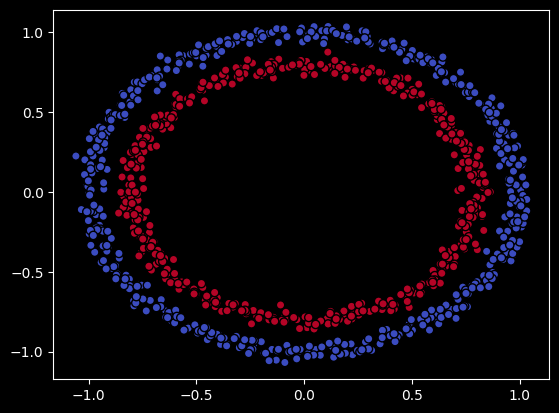

In [11]:
# Let's visualize the data
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")

In [12]:
## Check input and output shapes

X.shape, y.shape

((1000, 2), (1000,))

In [13]:
# Check the dtypes
type(X), type(y)
print(f"Data type of X: {(X.dtype)}, Data type of y: {(y.dtype)}")

Data type of X: float64, Data type of y: int64


In [ ]:
# X is np.array for dtype float64. WE need to convert it to torch tensor for dtype float32.
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
print(f"Data type of X: {(X.dtype)}, Data type of y: {(y.dtype)}")

Data type of X: torch.float32, Data type of y: torch.float32


In [15]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [18]:
# Set up the DEVICE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

In [19]:
from torch import nn


# Create a model
class CircleClassifierV0(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        # Create two linear layers capable of classifying the non-linear dataset
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

In [20]:
model_v0 = CircleClassifierV0()
model_v0

CircleClassifierV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
model_v0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.2150, -0.5039],
                      [-0.1148, -0.2633],
                      [-0.6028, -0.5168],
                      [ 0.4631,  0.5399],
                      [ 0.6312, -0.7039]])),
             ('layer_1.bias',
              tensor([-0.2461,  0.1987,  0.0933, -0.3179, -0.1519])),
             ('layer_2.weight',
              tensor([[-0.3200, -0.1043, -0.3989, -0.0647, -0.4036]])),
             ('layer_2.bias', tensor([0.1716]))])

In [22]:
# Let's create the same model using nn.Sequential module
model_v1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5), nn.Linear(in_features=5, out_features=1)
).to(DEVICE)

In [23]:
model_v1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.3599,  0.1870],
                      [ 0.0330, -0.6498],
                      [ 0.1383, -0.6907],
                      [-0.0884, -0.6598],
                      [ 0.5825,  0.3646]])),
             ('0.bias', tensor([-0.1401, -0.1638,  0.6905, -0.1888,  0.6787])),
             ('1.weight',
              tensor([[-0.3904,  0.3664,  0.1808, -0.2920, -0.0935]])),
             ('1.bias', tensor([-0.4235]))])

In [24]:
# Let's make some predictions from the untrained model
model_v1.eval()
with torch.inference_mode():
    untrained_preds = model_v1(X_test.to(DEVICE))
print(
    f"Length of predictions : {len(untrained_preds)} | Shape of the predictions : {untrained_preds.shape}"
)
print(
    f"Length of test samples : {len(X_test)} | Shape of the predictions : {X_test.shape}"
)
print("*" * 20)
print(
    "Let's compare the first 10 predictions with the first 10 grond truth values, shall we ? "
)
print(f"First 10 ground truth values : {y_test[:10]}")
print(f"First 10 prediction values from the untrained model : \n{untrained_preds[:10]}")


Length of predictions : 200 | Shape of the predictions : torch.Size([200, 1])
Length of test samples : 200 | Shape of the predictions : torch.Size([200, 2])
********************
Let's compare the first 10 predictions with the first 10 grond truth values, shall we ? 
First 10 ground truth values : tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])
First 10 prediction values from the untrained model : 
tensor([[-0.4521],
        [-0.5807],
        [-0.1321],
        [-0.5427],
        [-0.1591],
        [-0.2374],
        [-0.5780],
        [-0.4977],
        [-0.1315],
        [-0.5896]])


In [25]:
torch.eq(torch.Tensor([1, 2]), torch.Tensor([3, 2]))

tensor([False,  True])

In [26]:
torch.eq(torch.Tensor([[1, 2], [3, 4]]), torch.Tensor([[1, 4], [6, 4]])).sum().item()

2

In [27]:
torch.equal(torch.Tensor([1, 2]), torch.Tensor([1, 4]))

False

In [28]:
# torch.eq() returns element-wise values from the comparison
# torch.equal() returns a single value from the entire comparison. `True` only if the two tensors are of the same size and values

In [29]:
# Picking a loss and an optimizer for the classification problem

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v1.parameters(), lr=0.01)

In [30]:
# Let's calculate the accuracy


def calculate_acc(y_preds, y_test) -> float:
    correct: int = torch.eq(y_preds, y_test).sum().item()
    # print(f"Correct : {correct}")
    # print(f"Length of y_test : {len(y_test)}")
    accuracy: float = (correct / len(y_test)) * 100
    return accuracy

In [31]:
calculate_acc(torch.Tensor([1, 2]), torch.Tensor([1, 1]))

50.0

# Let's train the model
## Steps: 
1. Forward pass.
2. Calculate the loss.
3. Zero the gradients of the optimizer.
4. Backpropagation.
5. Perform the optimizer step (gradient descent)

In [32]:
# Lets view the first 5 outputs of the forward pass on the test data
model_v1.eval()
with torch.inference_mode():
    y_logits = model_v1(X_test.to(DEVICE))[:5]
y_logits

tensor([[-0.4521],
        [-0.5807],
        [-0.1321],
        [-0.5427],
        [-0.1591]])

In [33]:
y_logits.squeeze().shape

torch.Size([5])

In [34]:
y_test[:5].squeeze().shape

torch.Size([5])

In [35]:
# Let's use the sigmoid function to convert the logit scores to prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3889],
        [0.3588],
        [0.4670],
        [0.3676],
        [0.4603]])

In [36]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [37]:
# Set the seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put the data to the DEVICE
X_train, X_test = X_train.to(DEVICE), X_test.to(DEVICE)
y_train, y_test = y_train.to(DEVICE), y_test.to(DEVICE)

# Training Loop
NUM_EPOCHS = 200
epoch_count: list[int] = []
train_loss_count: list[float] = []
test_loss_count: list[float] = []

for epoch in range(NUM_EPOCHS):
    # set the model to train mode
    model_v1.train()
    # Forward pass
    y_train_logits: torch.Tensor = model_v1(X_train).squeeze()
    y_train_preds: torch.Tensor = torch.round(torch.sigmoid(y_train_logits))

    # Calculate the train loss
    train_loss = loss_fn(y_train_logits, y_train)

    # Calculate the train accuracy
    train_accuracy: float = calculate_acc(y_preds=y_train_preds, y_test=y_train)
    # Zero the gradients
    optimizer.zero_grad()

    # backpropagation
    train_loss.backward()

    # Optimizer step
    optimizer.step()

    # Testing
    model_v1.eval()
    with torch.inference_mode():
        y_test_logits = model_v1(X_test).squeeze()
        y_test_preds = torch.sigmoid(y_test_logits)
        test_loss = loss_fn(y_test_logits, y_test)
        # Calculate the accuracy
        test_accuracy = calculate_acc(y_test_preds, y_test)

    # Track the metrics
    epoch_count.append(epoch)
    train_loss_count.append(train_loss.item())
    test_loss_count.append(test_loss.item())
    if epoch % 10 == 0:
        print(
            f"Epoch : {epoch} | TrainLoss: {train_loss.item()}  TrainAcc: {train_accuracy} | TestLoss: {test_loss.item()} TestAcc : {test_accuracy}"
        )

Epoch : 0 | TrainLoss: 0.7113374471664429  TrainAcc: 49.25 | TestLoss: 0.7043079137802124 TestAcc : 0.0
Epoch : 10 | TrainLoss: 0.7097143530845642  TrainAcc: 46.5 | TestLoss: 0.7027702927589417 TestAcc : 0.0
Epoch : 20 | TrainLoss: 0.7082562446594238  TrainAcc: 44.375 | TestLoss: 0.7014015316963196 TestAcc : 0.0
Epoch : 30 | TrainLoss: 0.7069453597068787  TrainAcc: 42.75 | TestLoss: 0.7001836895942688 TestAcc : 0.0
Epoch : 40 | TrainLoss: 0.7057661414146423  TrainAcc: 41.75 | TestLoss: 0.6991007924079895 TestAcc : 0.0
Epoch : 50 | TrainLoss: 0.7047046422958374  TrainAcc: 41.0 | TestLoss: 0.6981384754180908 TestAcc : 0.0
Epoch : 60 | TrainLoss: 0.7037484645843506  TrainAcc: 40.375 | TestLoss: 0.697283923625946 TestAcc : 0.0
Epoch : 70 | TrainLoss: 0.7028862237930298  TrainAcc: 40.75 | TestLoss: 0.6965255737304688 TestAcc : 0.0
Epoch : 80 | TrainLoss: 0.7021080851554871  TrainAcc: 43.0 | TestLoss: 0.6958531737327576 TestAcc : 0.0
Epoch : 90 | TrainLoss: 0.7014050483703613  TrainAcc: 44.2

In [38]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target DEVICE
X_train, y_train = X_train.to(DEVICE), y_train.to(DEVICE)
X_test, y_test = X_test.to(DEVICE), y_test.to(DEVICE)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_v1(X_train).squeeze()
    y_pred = torch.round(
        torch.sigmoid(y_logits)
    )  # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)  # BCEWithLogitsLoss calculates loss using logits
    acc = calculate_acc(y_test=y_train, y_preds=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_v1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_v1(X_test).squeeze()
        test_pred = torch.round(
            torch.sigmoid(test_logits)
        )  # logits -> prediction probabilities -> prediction labels
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_acc(y_test=y_test, y_preds=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%"
        )

Epoch: 0 | Loss: 0.69687, Accuracy: 47.00% | Test Loss: 0.69194, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69521, Accuracy: 47.50% | Test Loss: 0.69134, Test Accuracy: 54.00%
Epoch: 200 | Loss: 0.69438, Accuracy: 48.25% | Test Loss: 0.69143, Test Accuracy: 53.00%


Epoch: 300 | Loss: 0.69389, Accuracy: 48.62% | Test Loss: 0.69174, Test Accuracy: 53.50%
Epoch: 400 | Loss: 0.69359, Accuracy: 48.88% | Test Loss: 0.69210, Test Accuracy: 53.00%
Epoch: 500 | Loss: 0.69339, Accuracy: 48.75% | Test Loss: 0.69245, Test Accuracy: 52.50%
Epoch: 600 | Loss: 0.69326, Accuracy: 49.00% | Test Loss: 0.69277, Test Accuracy: 52.50%
Epoch: 700 | Loss: 0.69317, Accuracy: 49.25% | Test Loss: 0.69306, Test Accuracy: 54.50%
Epoch: 800 | Loss: 0.69311, Accuracy: 51.25% | Test Loss: 0.69331, Test Accuracy: 47.00%
Epoch: 900 | Loss: 0.69307, Accuracy: 51.00% | Test Loss: 0.69352, Test Accuracy: 47.50%


In [39]:
# Let's download the helper function
from pathlib import Path

import requests

# Download helper function if doesnot already exists

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists. Skipping Download.")
else:
    print("Downloading the helper_functions.py file")
    response = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    )

    with open("helper_functions.py", "wb") as f:
        f.write(response.content)
    print("helper_functions.py downloaded!")

helper_functions.py already exists. Skipping Download.


In [40]:
from helper_functions import plot_decision_boundary, plot_predictions

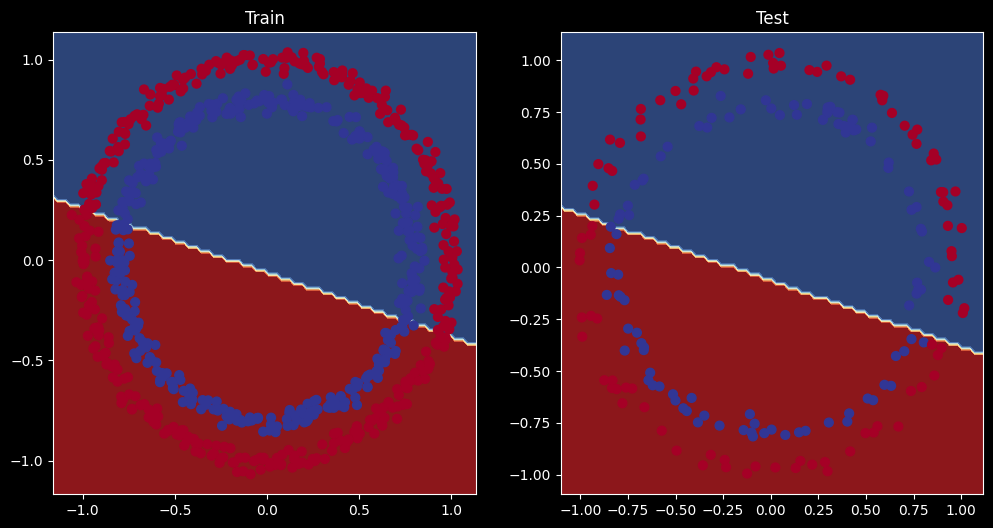

In [41]:
import matplotlib.pyplot as plt

# Lets' plot the decision boundaries for train and test set
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_v1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_v1, X_test, y_test)

In [56]:
# Let's build a multiclass classification data
# Necessary imports
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_blobs


In [101]:
RANDOM_SEED = 42
NUM_FEATURES = 2
NUM_CLASSES = 4
X_blob, y_blob = make_blobs(
    n_samples=2000,  # Training Samples
    n_features=NUM_FEATURES,  # X Features
    centers=NUM_CLASSES,  # y labels
    cluster_std=1.5,
    random_state=RANDOM_SEED,
)

In [102]:
X_blob.shape, y_blob.shape

((2000, 2), (2000,))

In [103]:
type(X_blob)

numpy.ndarray

In [104]:
np.unique_values(y_blob)

array([1, 2, 3, 0])

In [105]:
y_blob[:20]

array([1, 1, 2, 3, 3, 2, 2, 1, 0, 2, 2, 0, 3, 2, 1, 0, 2, 2, 1, 3])

In [106]:
# Let's convert np arrays to tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)
# X_blob, y_blob

In [107]:
# Let's split the data
X_train_blob, X_test_blob, y_train_blob, y_test_blob = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED
)

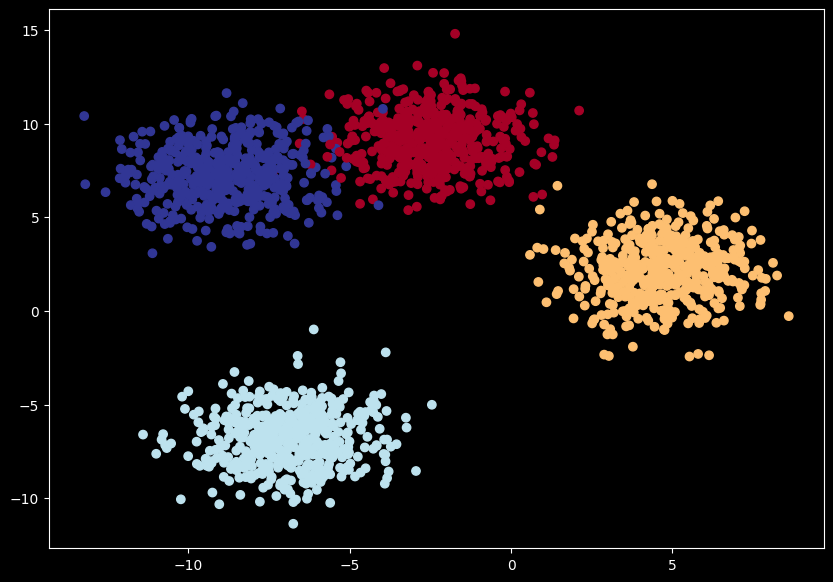

In [108]:
# Plot the data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)